# Delta SOH Hybrid Model Comparison

This notebook compares SOH prediction models with `--target-mode delta`, so each neural model predicts future SOH change rather than absolute SOH.

It supports both local Jupyter and Google Colab.

For Colab, use one of these data setup options:

1. Put the project folder at `Google Drive/MyDrive/UROP/` with this structure:

```text
MyDrive/UROP/
  compare_soh_models.py
  soh_gru_dsconv_pipeline.py
  raw_samples/
    *.pkl
```

2. Or upload a zip containing `compare_soh_models.py`, `soh_gru_dsconv_pipeline.py`, and `raw_samples/` when prompted.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import zipfile

import numpy as np
import pandas as pd

IN_COLAB = "google.colab" in sys.modules
DATA_DIR = "raw_samples"

if IN_COLAB:
    from google.colab import drive, files

    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/UROP")
    DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/UROP")

    if DRIVE_PROJECT_DIR.exists():
        print(f"Copying project from Drive: {DRIVE_PROJECT_DIR}")
        if PROJECT_DIR.exists():
            shutil.rmtree(PROJECT_DIR)
        shutil.copytree(DRIVE_PROJECT_DIR, PROJECT_DIR)
    else:
        print("Drive project folder not found at /content/drive/MyDrive/UROP")
        print("Upload a zip containing compare_soh_models.py, soh_gru_dsconv_pipeline.py, and raw_samples/.")
        uploaded = files.upload()
        zip_paths = [Path(name) for name in uploaded if name.lower().endswith(".zip")]
        if not zip_paths:
            raise FileNotFoundError("No zip file uploaded. Upload a project zip or create Drive/MyDrive/UROP.")
        extract_root = Path("/content/UROP_upload")
        if extract_root.exists():
            shutil.rmtree(extract_root)
        extract_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_paths[0]) as zf:
            zf.extractall(extract_root)
        candidates = list(extract_root.rglob("compare_soh_models.py"))
        if not candidates:
            raise FileNotFoundError("Uploaded zip does not contain compare_soh_models.py")
        PROJECT_DIR = candidates[0].parent
else:
    local_candidates = [
        Path.cwd(),
        Path(r"C:\Users\kyucho\Documents\UROP"),
    ]
    PROJECT_DIR = next(
        (p for p in local_candidates if (p / "compare_soh_models.py").exists()),
        local_candidates[0],
    )

SCRIPT = PROJECT_DIR / "compare_soh_models.py"
DATA_PATH = PROJECT_DIR / DATA_DIR

print("Colab:", IN_COLAB)
print("Project:", PROJECT_DIR)
print("Script exists:", SCRIPT.exists())
print("Data exists:", DATA_PATH.exists())
if not SCRIPT.exists():
    raise FileNotFoundError(f"Missing script: {SCRIPT}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data directory: {DATA_PATH}")
print("pkl files:", len(list(DATA_PATH.rglob("*.pkl"))))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying project from Drive: /content/drive/MyDrive/UROP
Colab: True
Project: /content/UROP
Script exists: True
Data exists: True
pkl files: 18


In [2]:
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))
    elif IN_COLAB:
        print("Colab GPU is not enabled. Use Runtime > Change runtime type > GPU.")
except Exception as exc:
    DEVICE = "cpu"
    print("Could not import torch, defaulting to CPU:", exc)

DEVICE

torch: 2.11.0+cu128
cuda available: True
gpu: Tesla T4


'cuda'

In [3]:
EARLY_CYCLE = 5
FIXED_LEN = 60
HORIZON = 50
EPOCHS = 10
BATCH_SIZE = 128
TARGET_MODE = "delta"
FEATURE_MODE = "practical"
SEED = 42

MODELS = [
    "persistence",
    "cpmlp",
    "cpmlp_gru_fusion",
    "cpmlp_gru_residual",
    "cpgru",
    "cpmlp_cpgru_fusion",
    "cpdsconv",
    "cpmlp_cpdsconv_fusion",
    "gru_dsconv",
    "cpmlp_dsconv_fusion",
]

OUTPUT_DIR = f"comparison_outputs_delta_all_hybrids_e{EPOCHS}_h{HORIZON}"
print("models:", ",".join(MODELS))
print("output:", PROJECT_DIR / OUTPUT_DIR)

models: persistence,cpmlp,cpmlp_gru_fusion,cpmlp_gru_residual,cpgru,cpmlp_cpgru_fusion,cpdsconv,cpmlp_cpdsconv_fusion,gru_dsconv,cpmlp_dsconv_fusion
output: /content/UROP/comparison_outputs_delta_all_hybrids_e10_h50


## Run Experiment

The residual model pretrains a CPMLP base for `EPOCHS` and then trains the residual branch for another `EPOCHS`, so it can take longer than the other models.

In Colab, results are also copied to `Google Drive/MyDrive/UROP_results/` after the run.

In [4]:
cmd = [
    sys.executable,
    str(SCRIPT),
    "--data-dir", DATA_DIR,
    "--output-dir", OUTPUT_DIR,
    "--fixed-len", str(FIXED_LEN),
    "--early-cycle", str(EARLY_CYCLE),
    "--horizon", str(HORIZON),
    "--epochs", str(EPOCHS),
    "--residual-base-epochs", str(EPOCHS),
    "--batch-size", str(BATCH_SIZE),
    "--models", ",".join(MODELS),
    "--target-mode", TARGET_MODE,
    "--feature-mode", FEATURE_MODE,
    "--seed", str(SEED),
    "--device", DEVICE,
]

print("Running command:")
print(" ".join(cmd))
subprocess.run(cmd, cwd=PROJECT_DIR, check=True)

if IN_COLAB:
    drive_results_dir = Path("/content/drive/MyDrive/UROP_results")
    drive_results_dir.mkdir(parents=True, exist_ok=True)
    local_output = PROJECT_DIR / OUTPUT_DIR
    drive_output = drive_results_dir / OUTPUT_DIR
    if drive_output.exists():
        shutil.rmtree(drive_output)
    shutil.copytree(local_output, drive_output)
    print("Copied results to:", drive_output)

Running command:
/usr/bin/python3 /content/UROP/compare_soh_models.py --data-dir raw_samples --output-dir comparison_outputs_delta_all_hybrids_e10_h50 --fixed-len 60 --early-cycle 5 --horizon 50 --epochs 10 --residual-base-epochs 10 --batch-size 128 --models persistence,cpmlp,cpmlp_gru_fusion,cpmlp_gru_residual,cpgru,cpmlp_cpgru_fusion,cpdsconv,cpmlp_cpdsconv_fusion,gru_dsconv,cpmlp_dsconv_fusion --target-mode delta --feature-mode practical --seed 42 --device cuda
Copied results to: /content/drive/MyDrive/UROP_results/comparison_outputs_delta_all_hybrids_e10_h50


## Overall Metrics

In [5]:
out_dir = PROJECT_DIR / OUTPUT_DIR
metrics = pd.read_csv(out_dir / "model_comparison_metrics.csv")
display(metrics)

metric_cols = ["RMSE", "MAE", "MAPE_percent", "R2"]
display(metrics.set_index("model")[metric_cols].style.format({
    "RMSE": "{:.6f}",
    "MAE": "{:.6f}",
    "MAPE_percent": "{:.3f}",
    "R2": "{:.4f}",
}))

,model,RMSE,MAE,MAPE_percent,R2,EOL_Error_cycles
0,cpmlp_cpgru_fusion,0.010015,0.004852,0.489495,0.983260,NaN
1,cpmlp_dsconv_fusion,0.010532,0.005282,0.547499,0.981488,NaN
2,cpmlp_gru_residual,0.011917,0.007640,0.749211,0.976300,NaN
3,persistence,0.012102,0.007289,0.771612,0.975558,NaN
4,cpmlp,0.013574,0.009926,0.973856,0.969253,NaN
5,cpdsconv,0.013818,0.009175,0.945070,0.968137,NaN
6,cpgru,0.014910,0.010596,1.036158,0.962899,NaN
7,gru_dsconv,0.014910,0.011291,1.104305,0.962899,NaN
8,cpmlp_cpdsconv_fusion,0.016538,0.010538,1.033713,0.954354,NaN
9,cpmlp_gru_fusion,0.026474,0.024677,2.429581,0.883036,NaN


,RMSE,MAE,MAPE_percent,R2
model,,,,
cpmlp_cpgru_fusion,0.010015,0.004852,0.489,0.9833
cpmlp_dsconv_fusion,0.010532,0.005282,0.547,0.9815
cpmlp_gru_residual,0.011917,0.007640,0.749,0.9763
persistence,0.012102,0.007289,0.772,0.9756
cpmlp,0.013574,0.009926,0.974,0.9693
cpdsconv,0.013818,0.009175,0.945,0.9681
cpgru,0.014910,0.010596,1.036,0.9629
gru_dsconv,0.014910,0.011291,1.104,0.9629
cpmlp_cpdsconv_fusion,0.016538,0.010538,1.034,0.9544


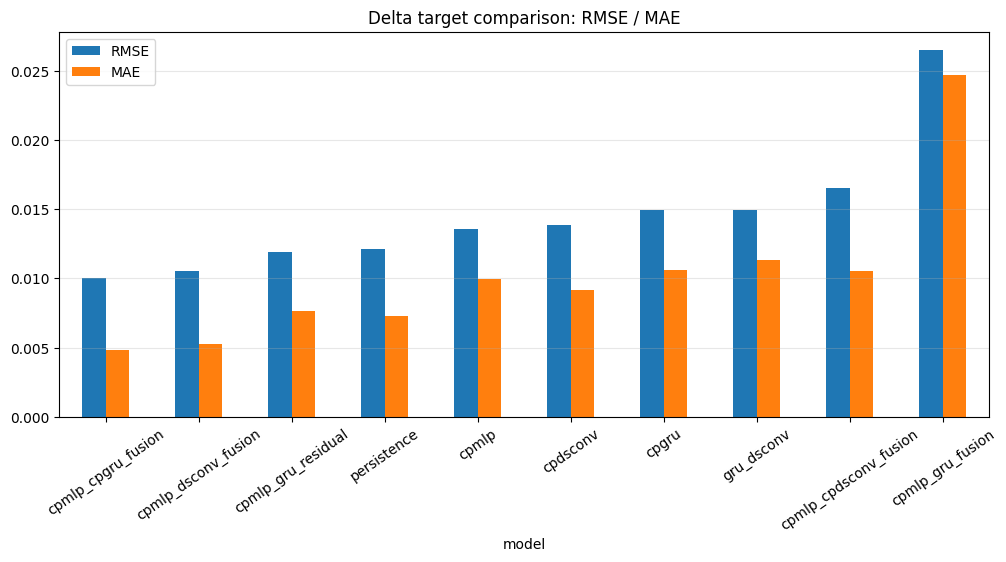

In [6]:
ax = metrics[0:5].plot.bar(x="model", y=["RMSE", "MAE"], figsize=(12, 5), rot=35)
ax.set_title("Delta target comparison: RMSE / MAE")
ax.grid(axis="y", alpha=0.3)

## Improvement Against CPMLP

In [7]:
pred_dir = out_dir / "predictions"
preds = {}
for path in sorted(pred_dir.glob("*_test_predictions.csv")):
    model = path.name.replace("_test_predictions.csv", "")
    preds[model] = pd.read_csv(path)

ref_model = "cpmlp"
rows = []
if ref_model in preds:
    ref = preds[ref_model]
    ref_err = (ref["actual_soh"] - ref["pred_soh"]).abs()
    for model, df in preds.items():
        err = (df["actual_soh"] - df["pred_soh"]).abs()
        delta = ref_err - err
        rows.append({
            "model": model,
            "mae": float(err.mean()),
            "mae_delta_vs_cpmlp": float(delta.mean()),
            "median_delta_vs_cpmlp": float(delta.median()),
            "improved_ratio_vs_cpmlp": float((delta > 0).mean()),
        })

improvement = pd.DataFrame(rows).sort_values("mae")
display(improvement.style.format({
    "mae": "{:.6f}",
    "mae_delta_vs_cpmlp": "{:.6f}",
    "median_delta_vs_cpmlp": "{:.6f}",
    "improved_ratio_vs_cpmlp": "{:.2%}",
}))

,model,mae,mae_delta_vs_cpmlp,median_delta_vs_cpmlp,improved_ratio_vs_cpmlp
3,cpmlp_cpgru_fusion,0.004852,0.005074,0.006286,88.21%
4,cpmlp_dsconv_fusion,0.005282,0.004644,0.007605,81.31%
9,persistence,0.007289,0.002637,0.005269,71.54%
6,cpmlp_gru_residual,0.007640,0.002286,0.002747,95.12%
0,cpdsconv,0.009175,0.000751,0.001788,68.29%
7,cpmlp,0.009926,0.000000,0.000000,0.00%
2,cpmlp_cpdsconv_fusion,0.010538,-0.000611,0.000673,59.32%
1,cpgru,0.010596,-0.000670,0.000160,53.59%
8,gru_dsconv,0.011291,-0.001364,-0.001926,27.29%
5,cpmlp_gru_fusion,0.024677,-0.014750,-0.015324,0.05%


## Per-Cell Metrics

In [8]:
rows = []
for model, df in preds.items():
    for cell_id, g in df.groupby("cell_id"):
        err = g["actual_soh"] - g["pred_soh"]
        rows.append({
            "cell_id": cell_id,
            "model": model,
            "n": len(g),
            "RMSE": float(np.sqrt(np.mean(err ** 2))),
            "MAE": float(np.mean(np.abs(err))),
            "Bias": float(np.mean(g["pred_soh"] - g["actual_soh"])),
        })

cell_metrics = pd.DataFrame(rows).sort_values(["cell_id", "RMSE"])
display(cell_metrics.style.format({
    "RMSE": "{:.6f}",
    "MAE": "{:.6f}",
    "Bias": "{:.6f}",
}))

,cell_id,model,n,RMSE,MAE,Bias
24,CALB_25_T25-1,gru_dsconv,45,0.000367,0.000294,-0.000094
21,CALB_25_T25-1,cpmlp,45,0.000684,0.000590,0.000590
0,CALB_25_T25-1,cpdsconv,45,0.002011,0.001980,-0.001980
9,CALB_25_T25-1,cpmlp_cpgru_fusion,45,0.004570,0.004556,0.004556
27,CALB_25_T25-1,persistence,45,0.008963,0.008956,0.008956
15,CALB_25_T25-1,cpmlp_gru_fusion,45,0.011067,0.011061,-0.011061
18,CALB_25_T25-1,cpmlp_gru_residual,45,0.011671,0.011666,-0.011666
12,CALB_25_T25-1,cpmlp_dsconv_fusion,45,0.017909,0.017905,-0.017905
3,CALB_25_T25-1,cpgru,45,0.043938,0.043936,-0.043936
6,CALB_25_T25-1,cpmlp_cpdsconv_fusion,45,0.069834,0.069833,-0.069833


## Delta Prediction Sanity Check

In [9]:
delta_rows = []
for model, df in preds.items():
    required = {"baseline_soh", "pred_delta_soh", "actual_delta_soh"}
    if required.issubset(df.columns):
        recon_err = (df["pred_soh"] - (df["baseline_soh"] + df["pred_delta_soh"])).abs().max()
        delta_rows.append({
            "model": model,
            "actual_delta_mean": float(df["actual_delta_soh"].mean()),
            "pred_delta_mean": float(df["pred_delta_soh"].mean()),
            "actual_delta_std": float(df["actual_delta_soh"].std()),
            "pred_delta_std": float(df["pred_delta_soh"].std()),
            "reconstruction_max_abs_err": float(recon_err),
        })

display(pd.DataFrame(delta_rows).style.format({
    "actual_delta_mean": "{:.6f}",
    "pred_delta_mean": "{:.6f}",
    "actual_delta_std": "{:.6f}",
    "pred_delta_std": "{:.6f}",
    "reconstruction_max_abs_err": "{:.2e}",
}))

,model,actual_delta_mean,pred_delta_mean,actual_delta_std,pred_delta_std,reconstruction_max_abs_err
0,cpdsconv,-0.007266,-0.007854,0.009680,0.006895,1.51e-07
1,cpgru,-0.007266,-0.017475,0.009680,0.005339,1.63e-07
2,cpmlp_cpdsconv_fusion,-0.007266,-0.016236,0.009680,0.009503,1.56e-07
3,cpmlp_cpgru_fusion,-0.007266,-0.010796,0.009680,0.002178,1.58e-07
4,cpmlp_dsconv_fusion,-0.007266,-0.008829,0.009680,0.003054,1.50e-07
5,cpmlp_gru_fusion,-0.007266,-0.031588,0.009680,0.002373,1.44e-07
6,cpmlp_gru_residual,-0.007266,-0.014333,0.009680,0.001472,1.66e-07
7,cpmlp,-0.007266,-0.016801,0.009680,0.001573,1.40e-07
8,gru_dsconv,-0.007266,-0.017965,0.009680,0.003006,1.58e-07
